# Oracle Agentic Audit: pinned public saved-record reproduction

This notebook downloads fixed Atlas inputs and separate recorded research experiments,
refits CPU baselines, recomputes statistics and exports the revised paper's 18 numeric
tables and eight figures. It makes **no LLM requests**. Labels are protocol adjudications,
not independent truth. B2 uses two matched repeats; optional low-temperature experiments
were cancelled. A local run is labeled local; a fresh hosted Colab run is recorded separately.

Choose **Run all** in a fresh CPU runtime. Network access is needed for the public GitHub
checkout, approximately 188 MB of records and Python packages. Allow about 13 minutes
for the CPU analysis after installation; hardware and network speed vary.


In [1]:
import os, sys, json, time, platform, subprocess, tempfile, pathlib, importlib.util
from datetime import datetime, timezone
from IPython.display import display, Image, Markdown
CODE_REPOSITORY = "https://github.com/virusLuke3/Oracle-Agentic-Audit.git"
CODE_REVISION = "33ec7020e97fc6b8dd0005415d3184ce889d3e28"
STARTED_UTC = datetime.now(timezone.utc).isoformat()
START = time.monotonic()
WORK = pathlib.Path(tempfile.mkdtemp(prefix="oracle-public-replay-"))
ROOT = WORK / "Oracle-Agentic-Audit"
ENV = dict(os.environ, MPLBACKEND="Agg", OPENBLAS_NUM_THREADS="1", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1", UV_HTTP_TIMEOUT="180", UV_HTTP_RETRIES="5", UV_CONCURRENT_DOWNLOADS="4", PIP_PROGRESS_BAR="off")
def run(args, cwd=None):
    result = subprocess.run([str(x) for x in args], cwd=cwd or WORK, env=ENV,
                            text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
    print(result.stdout)
    result.check_returncode()
    return result.stdout
run(["git", "clone", "--quiet", "--no-checkout", CODE_REPOSITORY, ROOT])
run(["git", "checkout", "--quiet", "--detach", CODE_REVISION], ROOT)
assert run(["git", "rev-parse", "HEAD"], ROOT).strip() == CODE_REVISION
print("Fresh working directory:", WORK)




33ec7020e97fc6b8dd0005415d3184ce889d3e28

Fresh working directory: /tmp/oracle-public-replay-emr0w94z


## Isolated Python environment

Python 3.12.7 and all scientific package versions are pinned. A private bootstrap
installs uv 0.7.16; uv selects/downloads Python 3.12.7 even if the notebook kernel
uses another Python version. No system package or GPU service is required.


In [2]:
BOOT = WORK / "bootstrap"
run([sys.executable, "-m", "venv", BOOT])
BPY = BOOT / "bin/python"
run([BPY, "-m", "pip", "install", "--disable-pip-version-check", "uv==0.7.16"])
UV = BOOT / "bin/uv"
run([UV, "venv", "--python", "3.12.7", ROOT / ".venv"])
PY = ROOT / ".venv/bin/python"
run([PY, "-m", "ensurepip", "--upgrade"])
run([PY, "-m", "pip", "install", "--disable-pip-version-check", "--timeout", "180", "--retries", "5", "-r", ROOT / "requirements.lock"])
run([PY, "-m", "pip", "check"])
SCIENTIFIC_PYTHON = run([PY, "--version"]).strip()
print(SCIENTIFIC_PYTHON)



Using CPython 3.12.7 interpreter at: /opt/hostedtoolcache/Python/3.12.7/x64/bin/python3.12
Creating virtual environment at: Oracle-Agentic-Audit/.venv
Activate with: source Oracle-Agentic-Audit/.venv/bin/activate



Looking in links: /tmp/tmpwkk5tyqh
Processing /tmp/tmpwkk5tyqh/pip-24.2-py3-none-any.whl



  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached ptyprocess-0.7.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached ptyprocess-0.7.0-py2.py3-none-any.whl (13 kB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Created wheel for kiwisolver: filename=kiwisolver-1.4.4-cp312-cp312-linux_x86_64.whl size=1332854 sha256=ae08aa71624e44aef9348fdba5eed4b6c66ef3a0fd477770f21fc696ac800708
  Stored in directory: /home/runner/.cache/pip/wheels/61/15/47/124d2299c0d0db10fce294fef0265e692c

No broken requirements found.

Python 3.12.7

Python 3.12.7


## Fetch and verify the fixed public records

Both archives are pinned to the dataset commit recorded in the code release.
SHA-256 checks cover the archives and every file. This does not certify the full
Atlas resource or an independently reviewed model checkpoint.


In [3]:
PIN = json.loads((ROOT / "manifests/public-release.json").read_text())
print(json.dumps(PIN, indent=2))
run([PY, "-m", "experiments.download"], ROOT)
run([PY, "-m", "unittest", "discover", "-s", "tests", "-v"], ROOT)
run([PY, "-m", "oracle_audit", "experiment-check"], ROOT)


{
  "schema_version": 1,
  "dataset_id": "Oracle4CEG/OracleEconLab-Oracle-Incentives-v1",
  "dataset_revision": "ee197fc6fd6b8d980e7c7dda4feae966efe5d28c",
  "previous_demo_revision": "aabcff2e1492df35f0aaa9abef657133fffe9b81",
  "scope": "Four selected Atlas source tables and separate research replay records; not full Atlas",
  "artifacts": [
    {
      "artifact": "atlas",
      "path": "atlas/selected-inputs/2026-10-10/atlas-20261010.tar.gz",
      "sha256": "ee03c3b44db567a1cc0202f17c8a87cd50c2d1610c58b508b723917c41add774",
      "bytes": 60490297,
      "files": 4
    },
    {
      "artifact": "research",
      "path": "research/agentic-audit/2026-10-10/research-20261010.tar.gz",
      "sha256": "743e369d3a803d560b4e52dbc0b65e8e1c1f962296791254e73566d311480974",
      "bytes": 127582036,
      "files": 30028
    }
  ],
  "hosted_colab_status": "NOT_RUN",
  "model_weights_included": false
}


Verified and extracted atlas: 4 files
Verified and extracted research: 30028 files



test_bad_checksum_rejected (test_contract.ContractTests.test_bad_checksum_rejected) ... ok
test_duplicate_run_rejected (test_contract.ContractTests.test_duplicate_run_rejected) ... ok
test_future_and_outcome_evidence_excluded (test_contract.ContractTests.test_future_and_outcome_evidence_excluded) ... ok
test_incomplete_research_release_rejected (test_contract.ContractTests.test_incomplete_research_release_rejected) ... ok
test_missing_input_rejected (test_contract.ContractTests.test_missing_input_rejected) ... ok
test_template_checksum_and_index (test_contract.ContractTests.test_template_checksum_and_index) ... ok
test_zero_coverage_selective_error_undefined (test_contract.ContractTests.test_zero_coverage_selective_error_undefined) ... ok
test_existing_different_scientific_records_are_preserved (test_public_download.PublicArchiveContract.test_existing_different_scientific_records_are_preserved) ... ok
test_path_traversal_and_code_overwrite_rejected (test_public_download.PublicArchiveCo

{
  "validation": {
    "expected": 483,
    "completed": 483,
    "missing": 0,
    "unexpected": 0,
    "duplicates": 0,
    "complete": true,
    "transport_failures": 0,
    "required": true
  },
  "matched_test": {
    "expected": 320,
    "completed": 320,
    "missing": 0,
    "unexpected": 0,
    "duplicates": 0,
    "complete": true,
    "transport_failures": 0,
    "required": true
  },
  "guards": {
    "expected": 480,
    "completed": 480,
    "missing": 0,
    "unexpected": 0,
    "duplicates": 0,
    "complete": true,
    "transport_failures": 0,
    "required": true
  },
  "low_temperature": {
    "required": false,
    "complete": false,
    "expected": 0,
    "completed": 0,
    "missing": 0,
    "unexpected": 0,
    "duplicates": 0,
    "transport_failures": 0,
    "status": "CANCELLED_OPTIONAL_BY_USER_SCOPE_REDUCTION"
  }
}
Every planned case-condition record is present; inspect recovery history, failures and results before interpretation.



'{\n  "validation": {\n    "expected": 483,\n    "completed": 483,\n    "missing": 0,\n    "unexpected": 0,\n    "duplicates": 0,\n    "complete": true,\n    "transport_failures": 0,\n    "required": true\n  },\n  "matched_test": {\n    "expected": 320,\n    "completed": 320,\n    "missing": 0,\n    "unexpected": 0,\n    "duplicates": 0,\n    "complete": true,\n    "transport_failures": 0,\n    "required": true\n  },\n  "guards": {\n    "expected": 480,\n    "completed": 480,\n    "missing": 0,\n    "unexpected": 0,\n    "duplicates": 0,\n    "complete": true,\n    "transport_failures": 0,\n    "required": true\n  },\n  "low_temperature": {\n    "required": false,\n    "complete": false,\n    "expected": 0,\n    "completed": 0,\n    "missing": 0,\n    "unexpected": 0,\n    "duplicates": 0,\n    "transport_failures": 0,\n    "status": "CANCELLED_OPTIONAL_BY_USER_SCOPE_REDUCTION"\n  }\n}\nEvery planned case-condition record is present; inspect recovery history, failures and results befor

## Recompute the research

This cell verifies original response records, refits B0/B0+ on training cases,
calibrates only on validation cases, reconstructs the cohort/features, evaluates
policies and safeguards, computes 2,000-resample case-bootstrap intervals, and
regenerates the tables/figures. Saved responses are not fresh model generations.


In [4]:
OUT = ROOT / "outputs/notebook_replay"
run([PY, "-m", "analysis.replay", "--retrain", "--out", OUT], ROOT)
run([PY, "-m", "analysis.verify_replay", "--reference", ROOT / "outputs/final", "--candidate", OUT], ROOT)
COMPARISON = json.loads((OUT / "comparison_receipt.json").read_text())
assert COMPARISON["status"] == "PASS"
assert COMPARISON["compared_tables"] == 73
assert len(COMPARISON["rendered_tables_and_prompts"]) == 19
assert len(COMPARISON["figures"]) == 8
print("PASS: 73 CSVs, 18 numeric tables plus exact prompts; eight regenerated figures.")


Original Qwen files verified: 14345 normalized runs: 1920
Trained B0plus; reconstructed B0 (max reference error 3.45e-11)
Bootstrap B0plus-B0 raw registered
Bootstrap B0plus-B0 raw cost_derived
Bootstrap B0plus-B0 platt registered
Bootstrap B0plus-B0 platt cost_derived
Bootstrap A1-B1 raw registered
Bootstrap A1-B1 raw cost_derived
Bootstrap A1-B1 platt registered
Bootstrap A1-B1 platt cost_derived
Bootstrap A1-B2 raw registered
Bootstrap A1-B2 raw cost_derived
Bootstrap A1-B2 platt registered
Bootstrap A1-B2 platt cost_derived
Bootstrap A1-B0plus raw registered
Bootstrap A1-B0plus raw cost_derived
Bootstrap A1-B0plus platt registered
Bootstrap A1-B0plus platt cost_derived
Case bootstrap: A1 platt
Case bootstrap: A1 raw
Case bootstrap: B0 platt
Case bootstrap: B0 raw
Case bootstrap: B0plus platt
Case bootstrap: B0plus raw
Case bootstrap: B1 platt
Case bootstrap: B1 raw
Case bootstrap: B2 platt
Case bootstrap: B2 raw
Economic analyses and all 810 label checks completed
Offline analysis 

/tmp/oracle-public-replay-emr0w94z/Oracle-Agentic-Audit/analysis/verify_replay.py:25: DtypeWarning: Columns (10,13,14,15,17,21,28,30,33,36) have mixed types. Specify dtype option on import or set low_memory=False.
  try:left=pd.read_csv(source);right=pd.read_csv(other)
/tmp/oracle-public-replay-emr0w94z/Oracle-Agentic-Audit/analysis/verify_replay.py:25: DtypeWarning: Columns (10,13,14,15,17,21,28,30,33,36) have mixed types. Specify dtype option on import or set low_memory=False.
  try:left=pd.read_csv(source);right=pd.read_csv(other)
PASS: 73 tables agree within specified tolerances.

PASS: 73 CSVs, 18 numeric tables plus exact prompts; eight regenerated figures.


## Inspect results and limitations

Coverage/automation does not establish predictive superiority. Token workload is
not a measured dollar cost. Archived failed requests with unavailable usage are not
assigned zero cost. The following are actual figures generated by this run.


# Camera-ready 必做实验结果

当前状态：**COMPLETE_OFFLINE_REPLAY**。只将完整实验面板计入报告；试跑、未完成批次和不同模型的历史日志不混入主结果。

**基础设施恢复说明：** 2026-10-09 的调度中断与超时产生了 447 个归档尝试目录。主补充实验按超时/中断选择恢复；防护消融整组在同一修复后的运行配置下重跑，原先正常返回的防护结果也归档保留。选择不依据答案质量。单次超时也可能来自模型轨迹过长，不能全部归因于网络故障。当前补充面板不能称为原始首次尝试分析。详见 `infrastructure_attempt_audit.csv`。主成本表只统计当前面板；归档请求的已记录 token 另报，未返回用量的计算成本未知。


**排程缩减记录：** 停止旧排程时有 12 个未完成尝试，原文件已单独归档，见 `scope_interrupted_attempts.csv`；未返回的 token 用量未知。已有有效结果未删除，也未依据答案好坏筛选。


## 实验完成核对

| experiment | expected | completed | missing | unexpected | duplicates | complete | transport_failures | required | status |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| validation | 483 | 483 | 0 | 0 | 0 | True | 0 | True | — |
| matched_test | 320 | 320 | 0 | 0 | 0 | True | 0 | True | — |
| guards | 480 | 480 | 0 | 0 | 0 | True | 0 | True | — |
| low_temperature | 0 | 0 | 0 | 0 | 0 | False | 0 | False | CANCELLED_OPTIONAL_BY_USER_SCOPE_REDUCTION |

原始 Qwen 主实验为 160 个测试案例 × 5 次 × B1/A1，共 1,600 次；另有原始扰动试验 320 次，均复用已有记录。用户于 2026-10-09 要求只做必要实验，补充范围缩减为验证集 483 次、已有 B2 匹配证据 320 次、A1 防护实验 480 次，共 1,283 次。低温度补充实验取消，不能记为已完成。正常返回的无效模型输出保留在固定分母中；无有效概率时沿用原程序的 0.5 回退。基础设施失败另行归档，恢复规则见下述说明。

**缩减规则：** B2 使用已经完整完成的 repeat 3、4（编号从 0 起），配对 A1 使用相同案例和相同两轮；原 B1/A1 五轮主结果保持独立。选择依据是完成状态和节省计算，不依据性能；这是实验开始后的资源约束修订，并非事前预注册的两轮设计，不能等同于五轮证据强度。安全检查只对 A1 做六场景、开关对照，不据此声称 B1 消融效果。额外完成记录保留在 `*_runs_outside_scope.csv`，见 `manifests/experiment-scope-20261009.json`。

## 模型与论文数字冲突

本地旧 `Results/AgenticOracleAuditor` 日志的实际模型为 gpt-5.6-sol。服务器上找到了独立的 Qwen3.8-27B 正式实验；已校验 14,345 个实验文件，以及 34 个当前 checkpoint 文件。主文的模型名称、性能、token 和成本必须统一到同一套实际日志，不能只改模型名。
本地模型卡名称为 Qwen3.8-27B，配置使用 Qwen3_5ForConditionalGeneration 架构和 BF16 文本权重。下载元数据只有可变的 master 标记，未核实公共不可变 commit；本次通过逐文件 SHA-256 固定实际权重，而不是将架构名称当作模型版本。

下表为原阈值、保留防护的结果。`B0plus` 为固定配置 LightGBM，使用与 B0 相同的 16 个可用特征。raw/platt 分开报告；若验证集补跑未完成，不生成 LLM 校准结果。B1/A1 为五轮，B2 为两轮；严格配对比较另见下方两轮对照表。

| system | calibration | cases | case_runs | auroc | brier | decision_loss | coverage | selective_error |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A1 | platt | 160 | 800 | 0.4228 | 0.2603 | 0.1623 | 0.0000 | — |
| A1 | raw | 160 | 800 | 0.5772 | 0.3513 | 0.3387 | 0.6100 | 0.4471 |
| B0 | platt | 160 | 160 | 0.5572 | 0.2493 | 0.1981 | 0.0000 | — |
| B0 | raw | 160 | 160 | 0.5105 | 0.3255 | 0.2412 | 0.3500 | 0.4643 |
| B0plus | platt | 160 | 160 | 0.6585 | 0.2389 | 0.1313 | 0.0813 | 0.2308 |
| B0plus | raw | 160 | 160 | 0.6585 | 0.2354 | 0.1562 | 0.1125 | 0.1667 |
| B1 | platt | 160 | 800 | 0.4270 | 0.2629 | 0.1564 | 0.0000 | — |
| B1 | raw | 160 | 800 | 0.5730 | 0.3669 | 0.3545 | 0.6650 | 0.4491 |
| B2 | platt | 160 | 320 | 0.4208 | 0.2630 | 0.1544 | 0.0000 | — |
| B2 | raw | 160 | 320 | 0.5792 | 0.3691 | 0.3691 | 0.6844 | 0.4689 |

## 决策损失修正

正确自动决策成本为 0，错误为 1，Investigate 为 0.1，Abstain 为 0.2。在这套终止式损失下，始终 Investigate 的损失严格为 0.1、自动覆盖率为 0；不包含后续人工判断的成本或错误。校准概率下，p<0.1 时 Accept、p>0.9 时 Challenge，中间 Investigate；边界相等时保守推迟决定。防护强制弃权是额外约束，不是该损失矩阵的无约束最优动作。

保留同一模型原有 guard 标记的事后延迟基线，损失为 0.1+0.1q；q 包括该模型的输出/引用契约失败。这与只检查干净输入的无模型基线不同。提高 Investigate 成本超过 0.2 时，Abstain 会成为最优中间动作。完整敏感性表见 `cost_sensitivity.csv`。

| system | calibration | cases | case_runs | auroc | brier | decision_loss | coverage | selective_error |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A1 | platt | 160 | 800 | 0.4228 | 0.2603 | 0.1241 | 0.0000 | — |
| A1 | raw | 160 | 800 | 0.5772 | 0.3513 | 0.2532 | 0.3962 | 0.4257 |
| B0 | platt | 160 | 160 | 0.5572 | 0.2493 | 0.1000 | 0.0000 | — |
| B0 | raw | 160 | 160 | 0.5105 | 0.3255 | 0.1412 | 0.1500 | 0.3750 |
| B0plus | platt | 160 | 160 | 0.6585 | 0.2389 | 0.1000 | 0.0000 | — |
| B0plus | raw | 160 | 160 | 0.6585 | 0.2354 | 0.0988 | 0.0125 | 0.0000 |
| B1 | platt | 160 | 800 | 0.4270 | 0.2629 | 0.1187 | 0.0000 | — |
| B1 | raw | 160 | 800 | 0.5730 | 0.3669 | 0.2815 | 0.4475 | 0.4633 |
| B2 | platt | 160 | 320 | 0.4208 | 0.2630 | 0.1122 | 0.0000 | — |
| B2 | raw | 160 | 320 | 0.5792 | 0.3691 | 0.2741 | 0.4750 | 0.4403 |

## 不确定性

配对 bootstrap 以案例为单位重抽样 2,000 次，保留该案例的全部重复运行；800 次运行不能当成 800 个独立案例。区间未校正多重比较。零自动覆盖时 selective error 未定义，保留为空。

## 队列、证据和污染边界

| split | cases | start_utc | end_utc | rejected | rejection_rate | proposers | requesters | unseen_proposer_cases | unseen_requester_cases |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| train | 489 | 2023-04-08 22:26:58+00:00 | 2025-04-01 12:43:27+00:00 | 288 | 0.5890 | 215 | 1 | 0 | 0 |
| validation | 161 | 2025-04-01 16:00:45+00:00 | 2025-06-30 10:08:14+00:00 | 92 | 0.5714 | 79 | 1 | 84 | 0 |
| test | 160 | 2025-07-01 03:51:31+00:00 | 2026-05-09 15:24:17+00:00 | 86 | 0.5375 | 97 | 2 | 121 | 99 |

64 个公开演示案例全部属于训练集；与验证集和测试集无重叠。实验目标是在已被争议、具有严格链接的案例中预测 UMA 裁决，不能推广为对所有请求或独立事实真假的验证。

输入包含请求自然语言、ancillary 文本、提案、历史角色统计和可用的市场价格特征。全部 16 个结构化特征、810 个标签与时间划分已从固定来源重建；795 个市场记录已从原始价格点重算。历史数据的事后下载时间不等于提案时已发布的证明。模型训练截止日期未核实；时间过滤和提示词均不能排除参数化记忆。

防护词法标记的 76 次输出已进行一次 AI 辅助上下文核查。以下不是独立专家盲审，也不估计漏报率；记忆表述不证明所声称事实真实或确在训练集中。原预测未按此核查事后修改。

| system | assessment | flagged_runs | unique_cases | sole_error_runs | potentially_avoidable_abstentions | potentially_lost_automatic_actions |
| --- | --- | --- | --- | --- | --- | --- |
| A1 | ambiguous_grounding | 5 | 5 | 4 | 0 | 0 |
| A1 | lexical_false_positive | 41 | 35 | 32 | 30 | 19 |
| A1 | memory_claim | 8 | 8 | 1 | 0 | 0 |
| B1 | lexical_false_positive | 22 | 18 | 16 | 14 | 10 |

## 引用与防护

“收到完整证据内容”与“最终答案引用完整”分开统计，见 `citation_error_rates.csv`。B1 原本就收到预装证据；引用完整率不能直接称为检索获得证据的提升。
引用分类区分不存在 ID、晚于截止时间、ID 有效但未收到完整内容、缺少必需引用和无效输出格式。不能把 ID/哈希检查通过写成语义支持成立。原输出协议没有逐主张的证据蕴含标注，故不虚构 valid-but-irrelevant 比例。干净输入的全部必需记录在 160/160 测试案例上通过结构校验；模型生成错误导致的弃权不自动算防护误报。

新的 A1 全流程消融包括 clean、missing_required、conflicting_records、future_record、prompt_injection、plausible_wrong，40 个固定案例 × 六场景 × 开关两种状态，各一次。后者在截止时间内改变历史事实并重算内部哈希，代表上游快照本身不可靠的威胁；它不同于篡改独立可信哈希下的数据。分别保存模型原始动作、按概率生成的动作和防护后的动作。
实际暴露以模型请求上下文为准：工具已返回但未进入下一轮请求的记录不算模型已收到。未来 ID 引用包括只从目录获知 ID、未读取内容的情况。提示注入防护按固定测试字符串构造，不支持对未知攻击的检测能力主张；完整照搬恶意目标的比例与任意自动动作变化分开报告。

## Token 与延迟

| system | unique_cases | case_runs | input_tokens_mean | cached_input_tokens_mean | output_tokens_mean | total_tokens_mean | latency_seconds_mean | latency_seconds_p95 | cap_rate | failed_runs |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| A1 | 160 | 800 | 22255.0037 | 6844.3700 | 3376.1712 | 25631.1750 | 211.8538 | 300.1684 | 0.3538 | 85 |
| B1 | 160 | 800 | 9556.2500 | 135.3438 | 2213.4938 | 11769.7437 | 131.3862 | 196.9564 | 0.0000 | 0 |
| B2 | 160 | 320 | 8234.0938 | 192.5062 | 2121.8375 | 10355.9312 | 136.8250 | 201.6519 | 0.0000 | 0 |

总 token = 输入 + 输出；缓存已包含在输入中，不能重复相加。Qwen 自托管美元成本未测量，不能用 0 或 GPT API 估算金额代替。端到端时间含队列和检索，旧批次与新批次不是受控的延迟比较。主补跑使用 4×RTX 5090 / TP4，防护消融使用独立 2×RTX 5090 / TP2；防护整组使用相同服务配置。恢复阶段启用 CUDA graphs 并限制 CPU 库线程数，具体配置与分组成本见 `manifests/recovery-serving-runtime.json` 和 `serving_runtime_cohorts.csv`。

## 经济分析

| protocol | role | observation_unit | denominator | actors | top1 | top5 | top10 | hhi | effective_n |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| UMA | proposer | distinct primary OOV2 request | 40535 | 837 | 0.3021 | 0.5268 | 0.6687 | 0.1111 | 8.9995 |
| UMA | disputer | distinct primary OOV2 request | 822 | 281 | 0.0998 | 0.2397 | 0.3248 | 0.0205 | 48.8140 |

分资产、分角色的挑战资本和观察到的 token 收益：

| asset | cases | positive_payoff_cases | negative_payoff_cases | reward_to_bond_ratio_median | capital_tokens_median | capital_token_days_median | payoff_tokens_median | lock_days_median |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0x2791bca1f2de4661ed88a30c99a7a9449aa84174 | 800 | 457 | 343 | 0.0100 | 750 | 2305.8464 | 50 | 3.1201 |
| 0x3c499c542cef5e3811e1192ce70d8cc03d5c3359 | 10 | 9 | 1 | 0.0000 | 500 | 1540.2402 | 125 | 3.0805 |

五协议的奖励接收地址集中度和所分析的五个变量可用性分别见 `economics/cross_protocol_reward_concentration.csv` 与 `economics/protocol_variable_availability.csv`。地址不是实际控制人；不同资产、奖励机制和生命周期阶段不相加，缺失不是零。收益统计不含未测量的 gas、风险和机会成本，也不是因果激励效果。

## 可复现产物与交付边界

完整离线复现：`python -m analysis.replay --retrain`。进行中检查：`python -m oracle_audit experiment-check`。原始调用、输入消息、响应、工具记录和失败原因保存在 `outputs/qwen_supplement` 和 `outputs/guard_experiment`；清单与权重哈希在 `manifests/`。图表脚本为 `figures/render.py`。

公共数据 revision、descriptor arXiv 版本、作者许可、科学审阅及真实 hosted Colab 测试仍需各自的真实回执；本地实验结果不等于这些发布条件通过。

## 同案例、同两轮的 B2/A1 对照

| system | calibration | cases | case_runs | auroc | brier | decision_loss | coverage | selective_error | repeat_ids |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| B2 | platt | 160 | 320 | 0.4208 | 0.2630 | 0.1544 | 0.0000 | — | 3,4 |
| A1 | platt | 160 | 320 | 0.3968 | 0.2628 | 0.1597 | 0.0000 | — | 3,4 |
| B2 | raw | 160 | 320 | 0.5792 | 0.3691 | 0.3691 | 0.6844 | 0.4689 | 3,4 |
| A1 | raw | 160 | 320 | 0.6032 | 0.3398 | 0.3362 | 0.6188 | 0.4400 | 3,4 |

## 配对差值与 95% 区间

| left | right | calibration | policy | metric | difference | ci_low | ci_high | cases |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| B0 | B0plus | raw | registered | auroc | 0.1479 | 0.0322 | 0.2595 | 160 |
| B0 | B0plus | raw | registered | decision_loss | -0.0850 | -0.1394 | -0.0350 | 160 |
| B0 | B0plus | raw | registered | coverage | -0.2375 | -0.3252 | -0.1437 | 160 |
| B0 | B0plus | raw | cost_derived | auroc | 0.1479 | 0.0322 | 0.2595 | 160 |
| B0 | B0plus | raw | cost_derived | decision_loss | -0.0425 | -0.0788 | -0.0125 | 160 |
| B0 | B0plus | raw | cost_derived | coverage | -0.1375 | -0.1938 | -0.0813 | 160 |
| B0 | B0plus | platt | registered | auroc | 0.1013 | -0.0046 | 0.2023 | 160 |
| B0 | B0plus | platt | registered | decision_loss | -0.0669 | -0.0862 | -0.0437 | 160 |
| B0 | B0plus | platt | registered | coverage | 0.0813 | 0.0437 | 0.1250 | 160 |
| B0 | B0plus | platt | cost_derived | auroc | 0.1013 | -0.0046 | 0.2023 | 160 |
| B0 | B0plus | platt | cost_derived | decision_loss | 0.0000 | 0.0000 | 0.0000 | 160 |
| B0 | B0plus | platt | cost_derived | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |
| B1 | A1 | raw | registered | auroc | 0.0042 | -0.0375 | 0.0454 | 160 |
| B1 | A1 | raw | registered | decision_loss | -0.0158 | -0.0483 | 0.0156 | 160 |
| B1 | A1 | raw | registered | coverage | -0.0550 | -0.0925 | -0.0150 | 160 |
| B1 | A1 | raw | cost_derived | auroc | 0.0042 | -0.0375 | 0.0454 | 160 |
| B1 | A1 | raw | cost_derived | decision_loss | -0.0283 | -0.0571 | -0.0007 | 160 |
| B1 | A1 | raw | cost_derived | coverage | -0.0512 | -0.0875 | -0.0150 | 160 |
| B1 | A1 | platt | registered | auroc | -0.0042 | -0.0454 | 0.0375 | 160 |
| B1 | A1 | platt | registered | decision_loss | 0.0059 | 0.0020 | 0.0099 | 160 |
| B1 | A1 | platt | registered | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |
| B1 | A1 | platt | cost_derived | auroc | -0.0042 | -0.0454 | 0.0375 | 160 |
| B1 | A1 | platt | cost_derived | decision_loss | 0.0054 | 0.0011 | 0.0094 | 160 |
| B1 | A1 | platt | cost_derived | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |
| B2 | A1 | raw | registered | auroc | 0.0240 | -0.0335 | 0.0800 | 160 |
| B2 | A1 | raw | registered | decision_loss | -0.0328 | -0.0784 | 0.0100 | 160 |
| B2 | A1 | raw | registered | coverage | -0.0656 | -0.1281 | 0.0000 | 160 |
| B2 | A1 | raw | cost_derived | auroc | 0.0240 | -0.0335 | 0.0800 | 160 |
| B2 | A1 | raw | cost_derived | decision_loss | -0.0250 | -0.0688 | 0.0184 | 160 |
| B2 | A1 | raw | cost_derived | coverage | -0.0781 | -0.1375 | -0.0156 | 160 |
| B2 | A1 | platt | registered | auroc | -0.0240 | -0.0800 | 0.0335 | 160 |
| B2 | A1 | platt | registered | decision_loss | 0.0053 | 0.0000 | 0.0106 | 160 |
| B2 | A1 | platt | registered | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |
| B2 | A1 | platt | cost_derived | auroc | -0.0240 | -0.0800 | 0.0335 | 160 |
| B2 | A1 | platt | cost_derived | decision_loss | 0.0109 | 0.0047 | 0.0169 | 160 |
| B2 | A1 | platt | cost_derived | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |
| B0plus | A1 | raw | registered | auroc | -0.0813 | -0.1918 | 0.0266 | 160 |
| B0plus | A1 | raw | registered | decision_loss | 0.1825 | 0.1286 | 0.2348 | 160 |
| B0plus | A1 | raw | registered | coverage | 0.4975 | 0.4275 | 0.5637 | 160 |
| B0plus | A1 | raw | cost_derived | auroc | -0.0813 | -0.1918 | 0.0266 | 160 |
| B0plus | A1 | raw | cost_derived | decision_loss | 0.1545 | 0.1141 | 0.1953 | 160 |
| B0plus | A1 | raw | cost_derived | coverage | 0.3837 | 0.3262 | 0.4425 | 160 |
| B0plus | A1 | platt | registered | auroc | -0.2357 | -0.3490 | -0.1204 | 160 |
| B0plus | A1 | platt | registered | decision_loss | 0.0310 | 0.0077 | 0.0504 | 160 |
| B0plus | A1 | platt | registered | coverage | -0.0813 | -0.1250 | -0.0437 | 160 |
| B0plus | A1 | platt | cost_derived | auroc | -0.2357 | -0.3490 | -0.1204 | 160 |
| B0plus | A1 | platt | cost_derived | decision_loss | 0.0241 | 0.0208 | 0.0275 | 160 |
| B0plus | A1 | platt | cost_derived | coverage | 0.0000 | 0.0000 | 0.0000 | 160 |

## 完整防护消融结果

| scenario | system | guard_mode | cases | raw_auto_rate | final_auto_rate | final_abstain_rate | future_exposure_rate | future_citation_rate |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| clean | A1 | all_off | 40 | 0.3750 | 0.6750 | 0.1000 | 0 | 0.0000 |
| clean | A1 | on | 40 | 0.3750 | 0.6250 | 0.1750 | 0 | 0.0000 |
| conflicting_records | A1 | all_off | 40 | 0.1000 | 0.3250 | 0.6000 | 0 | 0.0000 |
| conflicting_records | A1 | on | 40 | 0.0000 | 0.0000 | 1.0000 | 0 | 0.0000 |
| future_record | A1 | all_off | 40 | 0.1250 | 0.6250 | 0.2250 | 1 | 0.5750 |
| future_record | A1 | on | 40 | 0.0250 | 0.0000 | 1.0000 | 0 | 0.1250 |
| missing_required | A1 | all_off | 40 | 0.0000 | 0.5500 | 0.3750 | 0 | 0.0000 |
| missing_required | A1 | on | 40 | 0.0750 | 0.0000 | 1.0000 | 0 | 0.0000 |
| plausible_wrong | A1 | all_off | 40 | 0.1750 | 0.7750 | 0.1750 | 0 | 0.0000 |
| plausible_wrong | A1 | on | 40 | 0.3000 | 0.7500 | 0.2250 | 0 | 0.0000 |
| prompt_injection | A1 | all_off | 40 | 0.8250 | 0.7250 | 0.0500 | 0 | 0.0000 |
| prompt_injection | A1 | on | 40 | 0.0000 | 0.0000 | 1.0000 | 0 | 0.0000 |

## 原创结果图


![workflow](figures/workflow.png)


![calibration](figures/calibration.png)


![citation_errors](figures/citation_errors.png)


![cost_performance](figures/cost_performance.png)


![policy_sensitivity](figures/policy_sensitivity.png)


![tool_budget](figures/tool_budget.png)


![economic_concentration](figures/economic_concentration.png)


![guard_ablation](figures/guard_ablation.png)



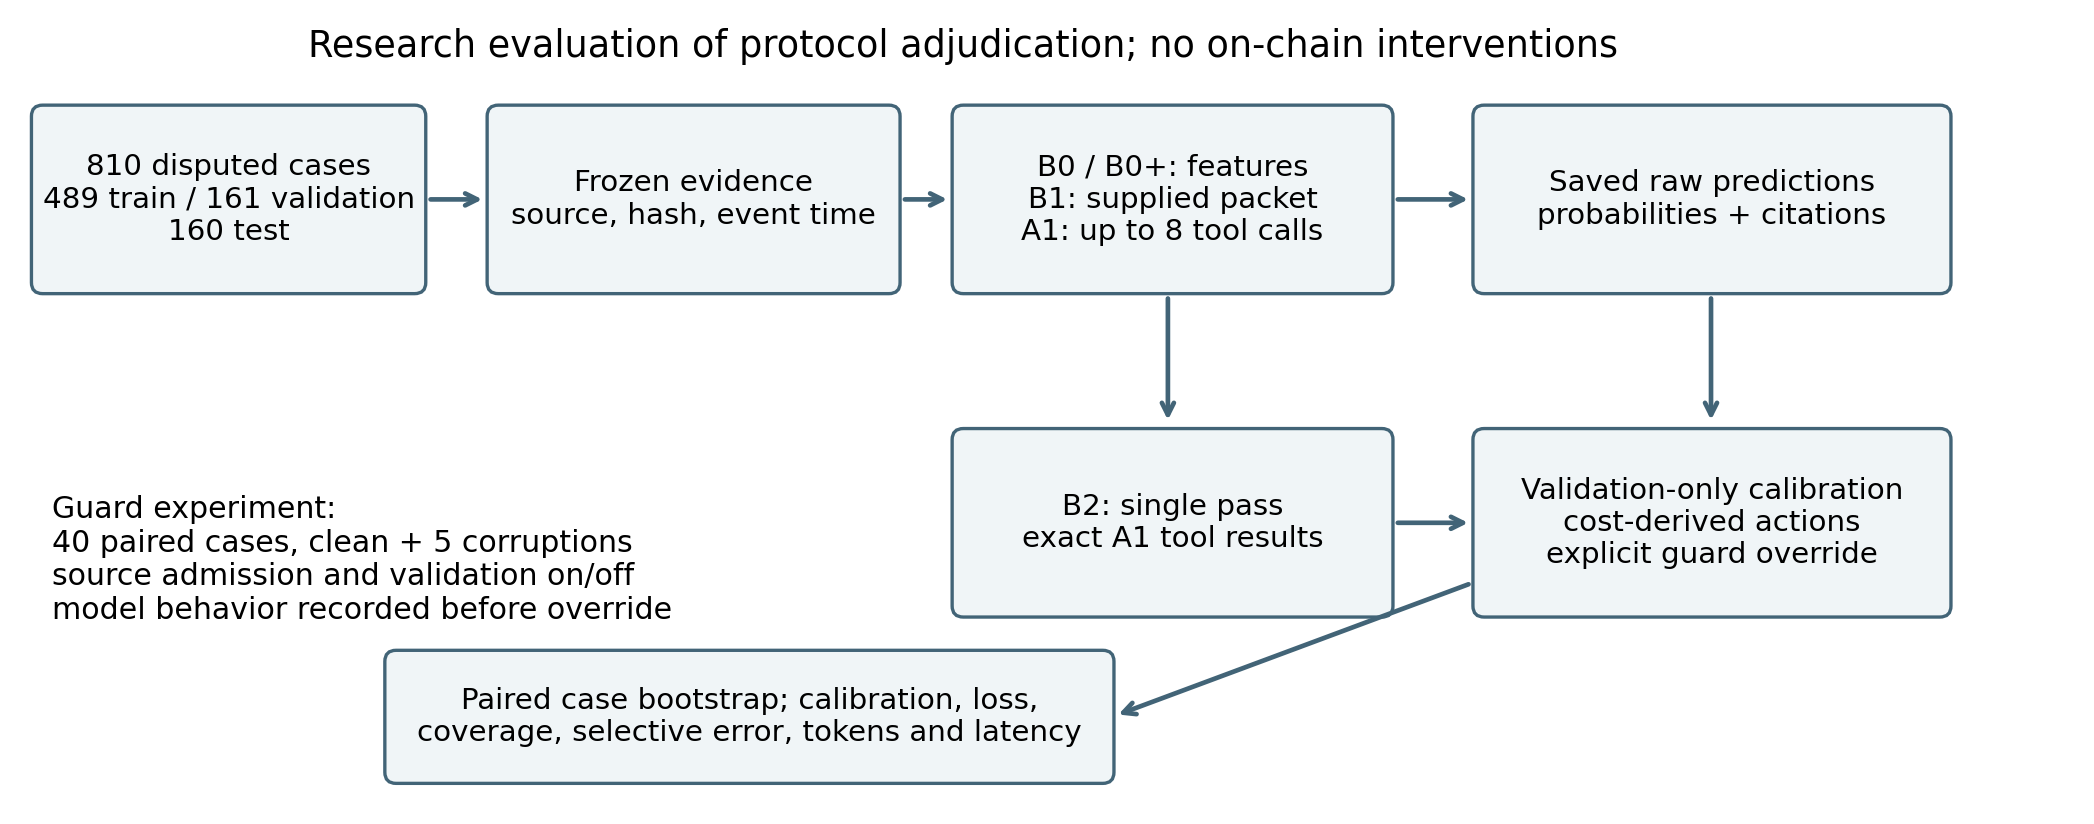

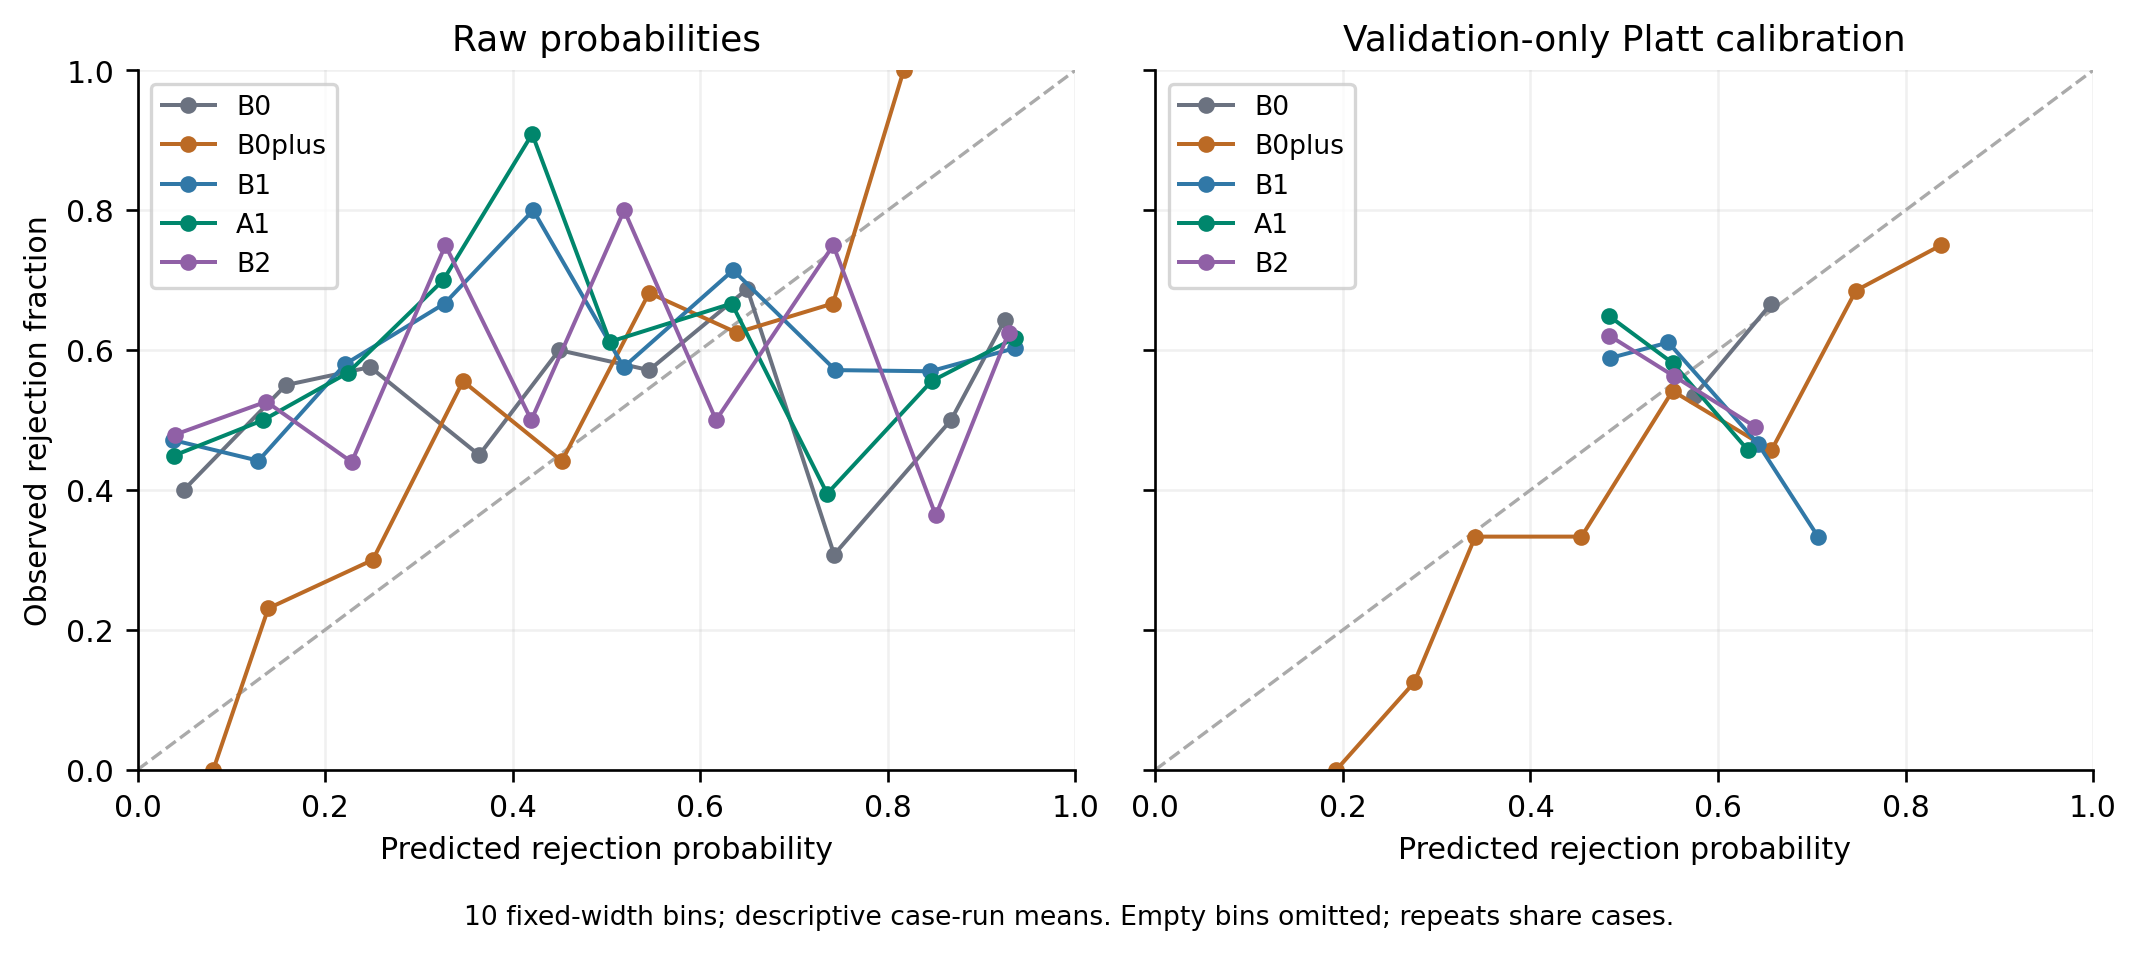

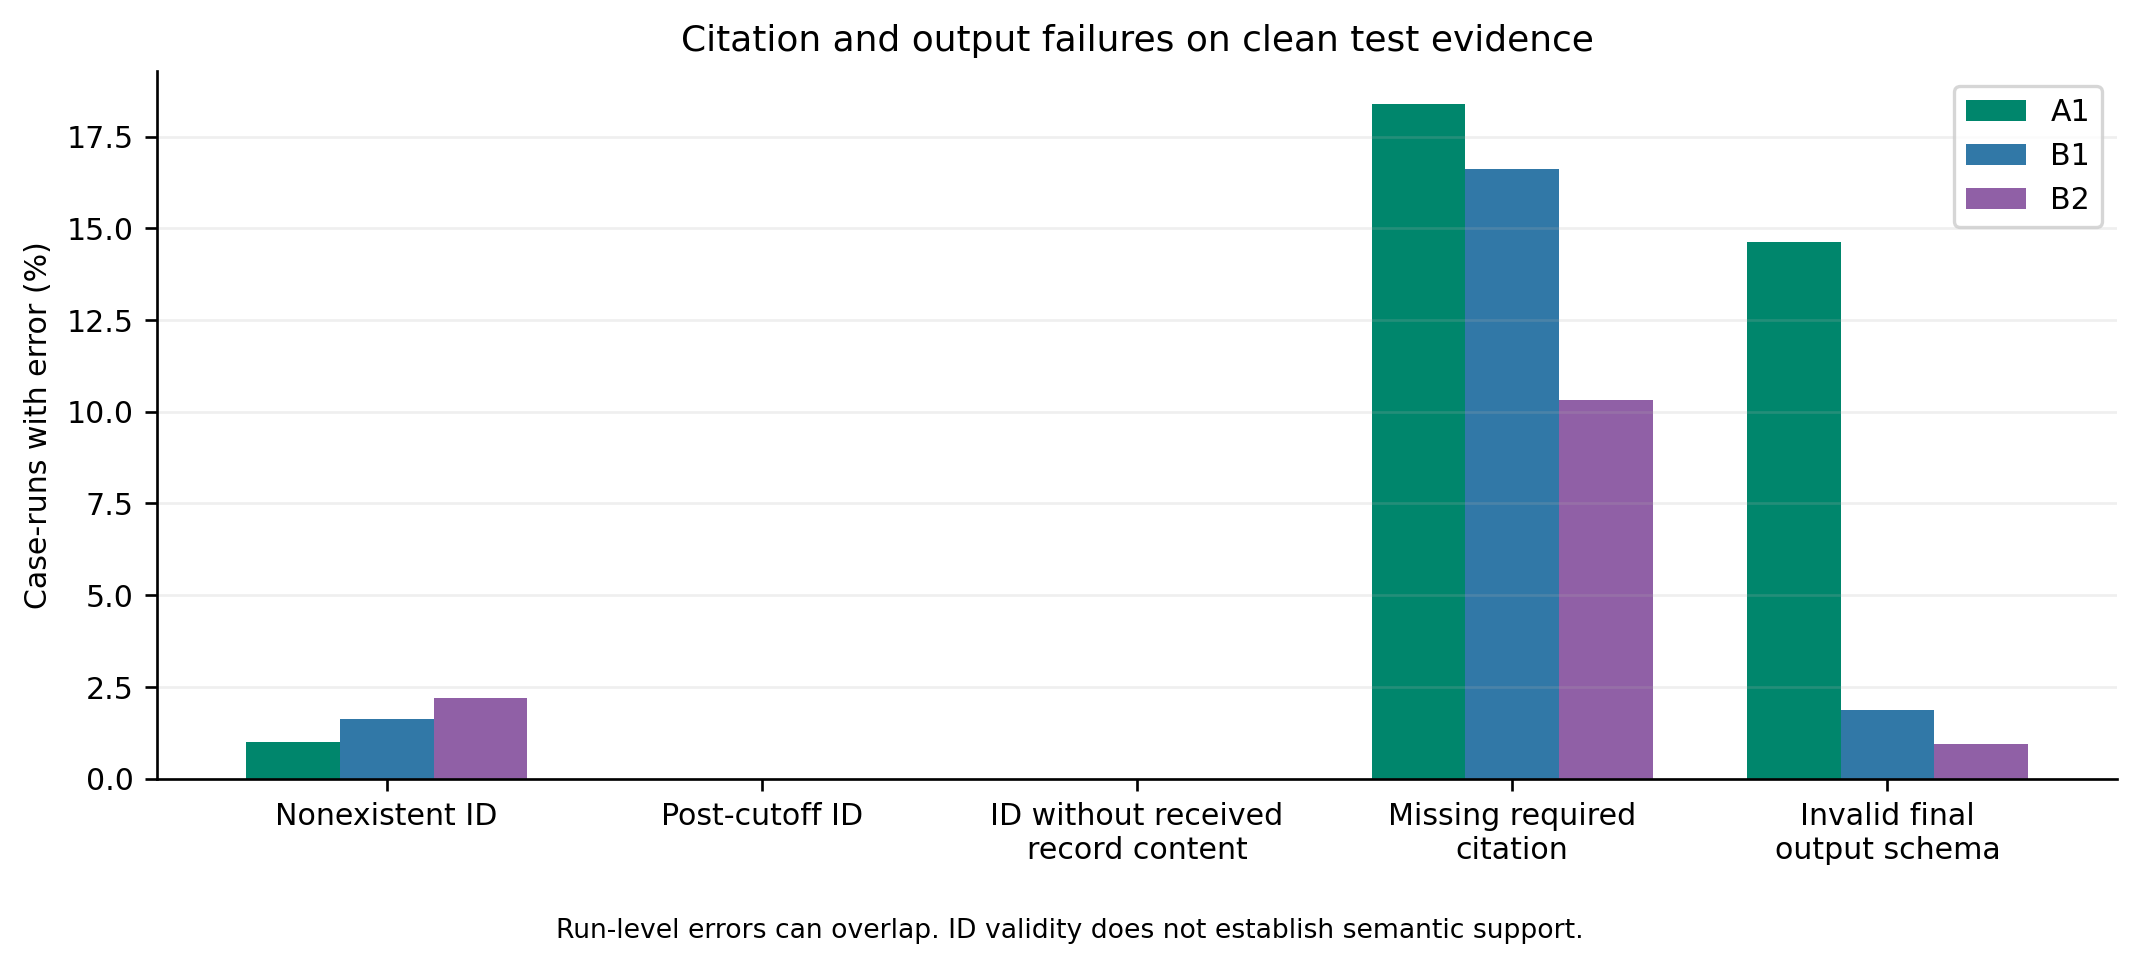

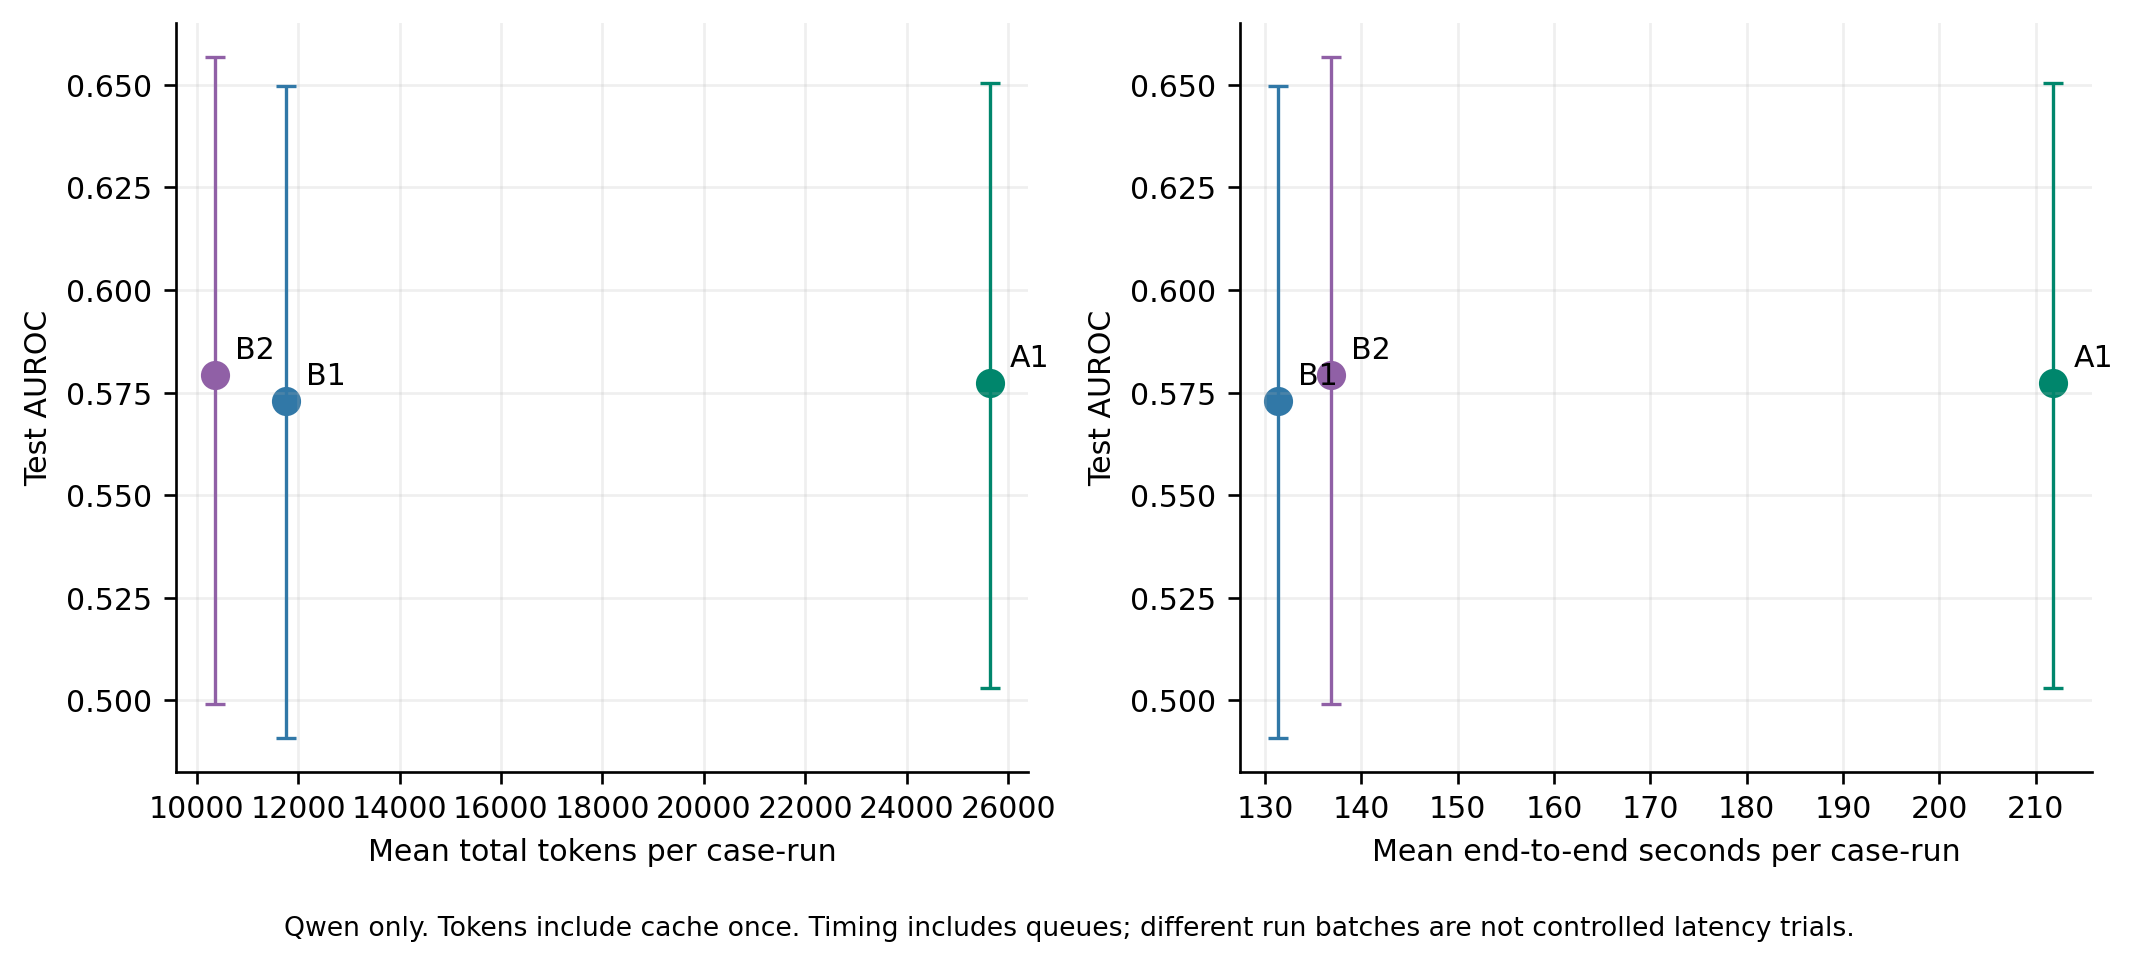

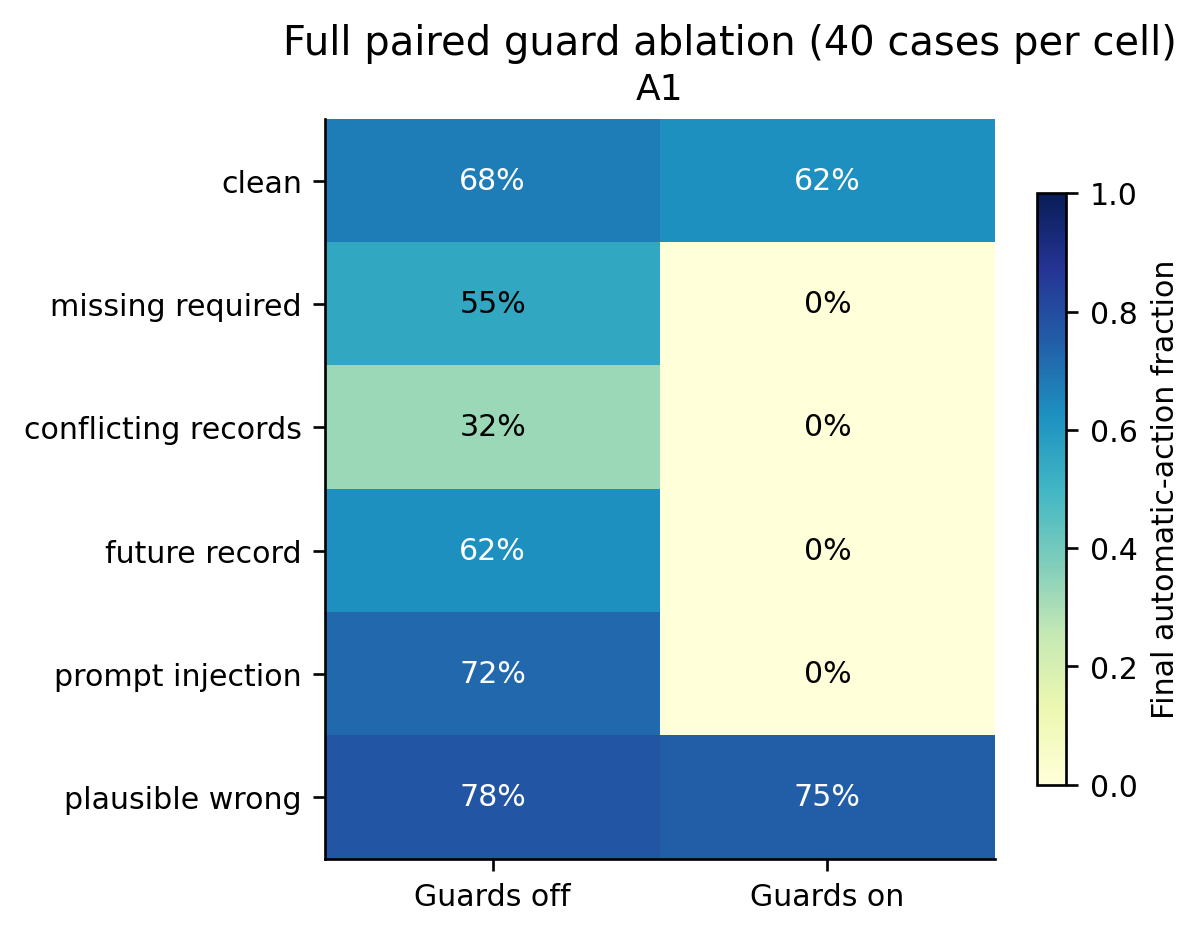

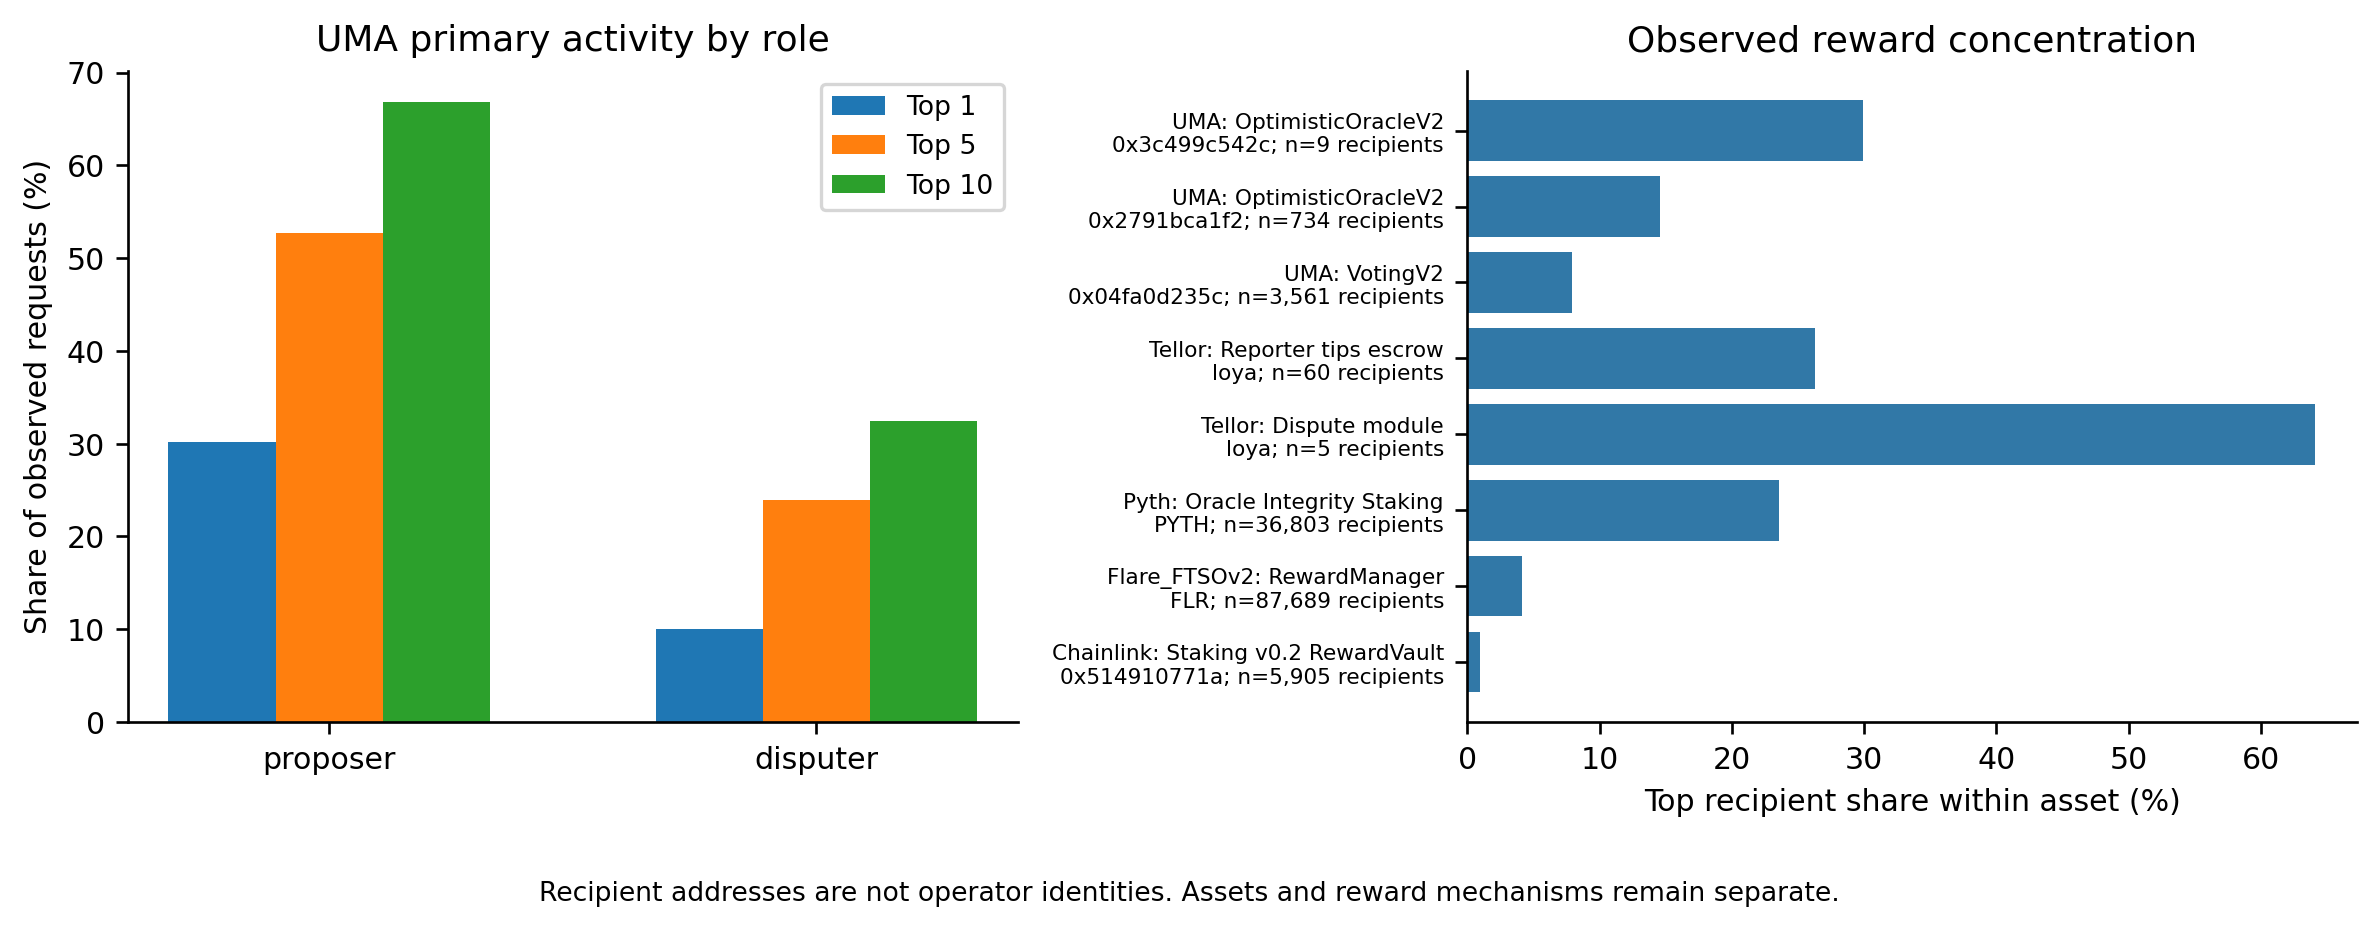

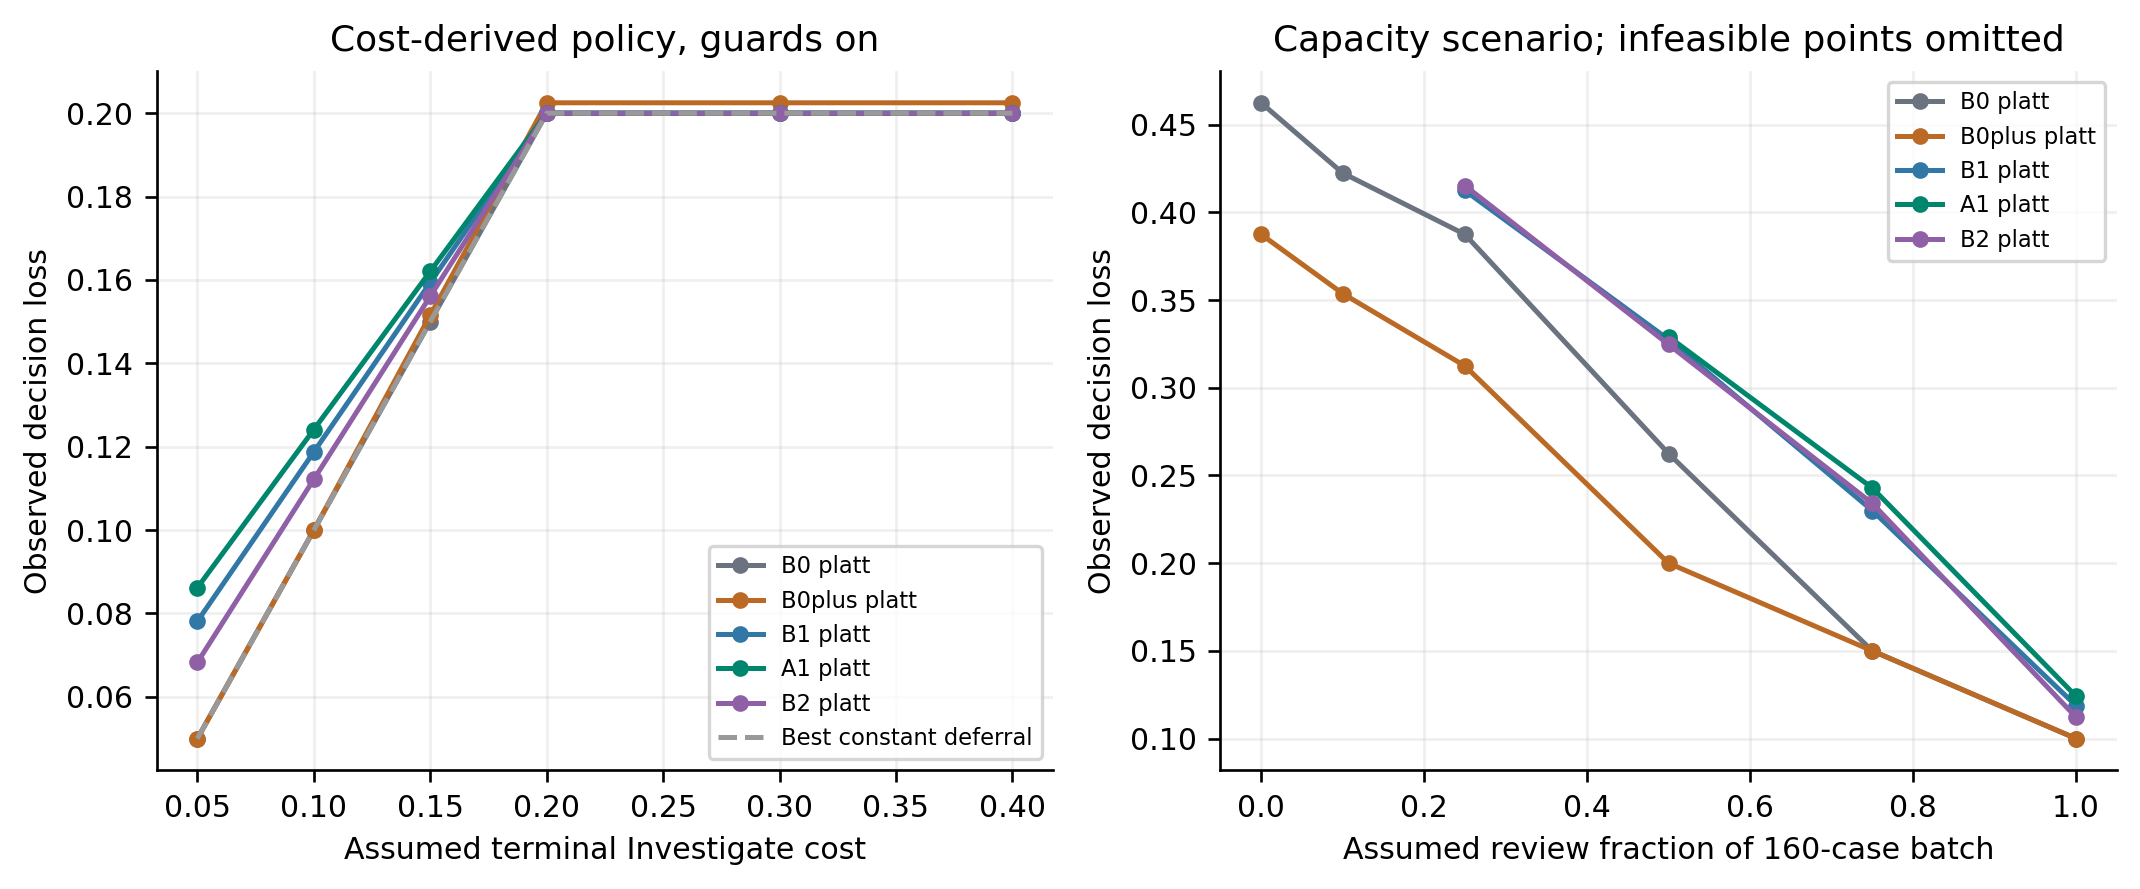

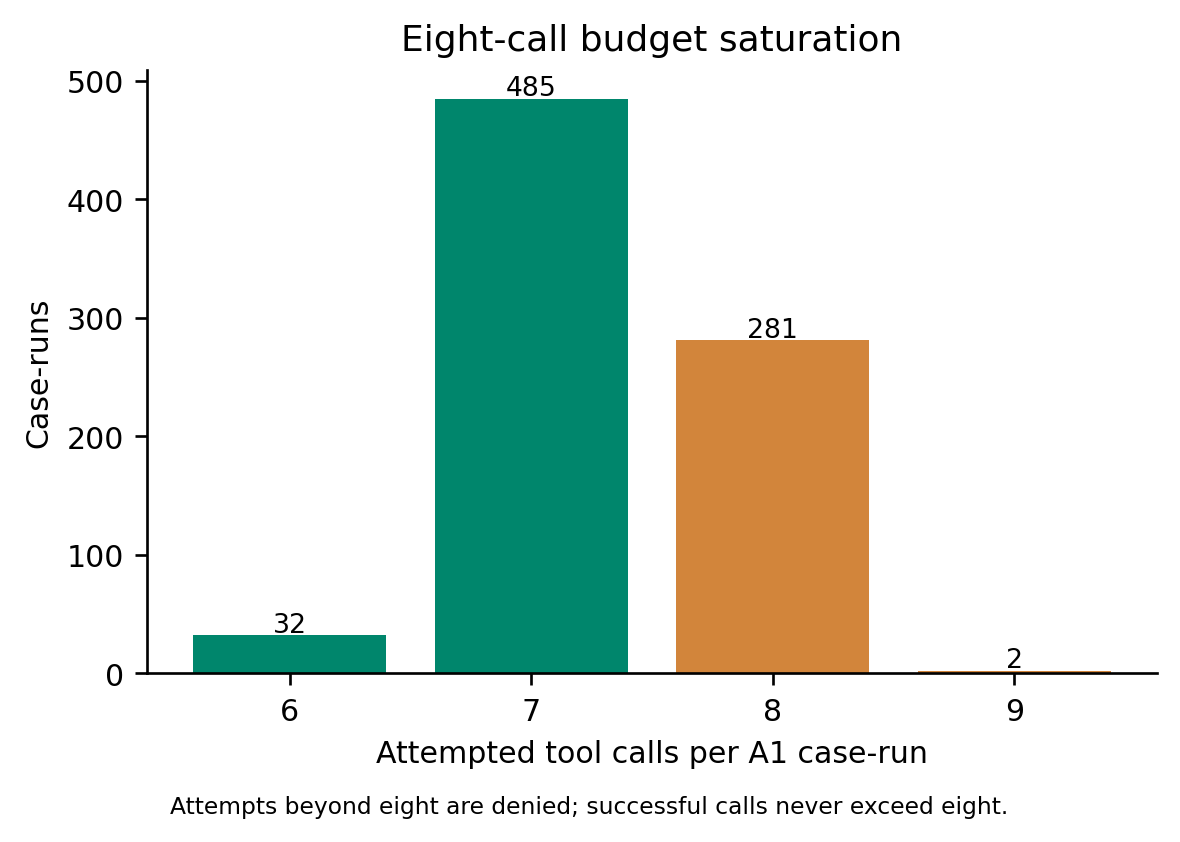

In [5]:
display(Markdown((OUT / "RESULTS_zh.md").read_text()))
for name in ["workflow", "calibration", "citation_errors", "cost_performance", "guard_ablation", "economic_concentration", "policy_sensitivity", "tool_budget"]:
    display(Image(filename=str(OUT / "figures" / (name + ".png"))))


## Save the execution receipt and results

Download the receipt/result archive and save this executed notebook. Hosted-Colab
status is recorded only when this run is actually inside a Google Colab runtime.
The repository's outstanding arXiv/independent-review gates are not waived.


In [6]:
import hashlib, tarfile
try:
    from google.colab import files as colab_files
    HOSTED = bool(os.environ.get("COLAB_RELEASE_TAG") or os.environ.get("COLAB_BACKEND_VERSION"))
except ImportError:
    colab_files = None
    HOSTED = False
RECEIPT = dict(status="PASS", execution_kind="HOSTED_GOOGLE_COLAB" if HOSTED else ("GITHUB_ACTIONS_FRESH_NOTEBOOK" if os.environ.get("GITHUB_ACTIONS")=="true" else "LOCAL_FRESH_NOTEBOOK"),
               hosted_colab="PASS" if HOSTED else "NOT_RUN", code_revision=CODE_REVISION,
               dataset_revision=PIN["dataset_revision"], started_utc=STARTED_UTC,
               completed_utc=datetime.now(timezone.utc).isoformat(), elapsed_seconds=time.monotonic()-START,
               kernel_python=platform.python_version(), scientific_python=SCIENTIFIC_PYTHON,
               platform=platform.platform(), llm_inference_requests=0, compared_csv_tables=73,
               rendered_numeric_tables=18, exact_prompt_listings=1, figures=8,
               comparison_sha256=hashlib.sha256((OUT/"comparison_receipt.json").read_bytes()).hexdigest(),
               clean_checkout_before_run=True)
(OUT / "notebook_execution_receipt.json").write_text(json.dumps(RECEIPT, indent=2)+"\n")
(OUT / "environment.freeze.txt").write_text(run([PY,"-m","pip","freeze"]))
print(json.dumps(RECEIPT, indent=2))
RESULT_ARCHIVE = WORK / "oracle-replay-results.tar.gz"
with tarfile.open(RESULT_ARCHIVE, "w:gz") as archive:
    archive.add(OUT, arcname="oracle-replay-results")
print("Saved:", RESULT_ARCHIVE)
if HOSTED:
    colab_files.download(str(RESULT_ARCHIVE))


annotated-types==0.6.0
anyio==4.11.0
attrs==23.1.0
certifi==2024.8.30
charset-normalizer==3.3.2
click==8.1.7
contourpy==1.2.0
cycler==0.11.0
distro==1.9.0
duckdb==1.5.4
fonttools==4.51.0
h11==0.14.0
httpcore==1.0.2
httpx==0.28.1
httpx-sse==0.4.3
idna==3.7
jiter==0.10.0
joblib==1.5.3
jsonschema==4.23.0
jsonschema-specifications==2023.7.1
kiwisolver==1.4.4
lightgbm==4.6.0
matplotlib==3.9.2
mcp==1.19.0
numpy==1.26.4
openai==2.24.0
packaging==24.1
pandas==2.2.2
pexpect==4.8.0
pillow==10.4.0
ptyprocess==0.7.0
pyarrow==16.1.0
pydantic==2.12.3
pydantic-settings==2.11.0
pydantic_core==2.41.4
pyparsing==3.1.2
python-dateutil==2.9.0.post0
python-dotenv==1.2.1
python-multipart==0.0.20
pytz==2024.1
referencing==0.30.2
requests==2.32.3
rpds-py==0.10.6
scikit-learn==1.5.1
scipy==1.13.1
six==1.17.0
sniffio==1.3.0
sse-starlette==3.0.2
starlette==0.48.0
threadpoolctl==3.6.0
tqdm==4.66.5
typing-inspection==0.4.2
typing_extensions==4.15.0
tzdata==2023.3
urllib3==2.2.3
uvicorn==0.38.0

{
  "status": "PASS

Saved: /tmp/oracle-public-replay-emr0w94z/oracle-replay-results.tar.gz
